In [2]:
#MODULE 1 : Data Collection

#IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib


In [5]:
df = pd.read_csv(r"C:\Users\ACER\Downloads\IBM-PBEL\UnnatiYadav(Batch 9)--AI-Driven Student Performance Prediction System\dataset\student_performance_prediction_dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [6]:
#MODULE 3 : Data Understanding
df.head()

,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,...,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,final_grade,grade_category,pass_fail
0,1,21,Male,1.645404,79.154521,8.230886,96.053840,7.719620,1.871170,1.447894,...,4.018412,Medium,Master,Yes,Mobile,Private,Coding Club,59.248749,D,Pass
1,2,18,Male,4.462126,72.526685,6.139219,53.024821,6.754758,5.630071,1.891288,...,3.268642,Medium,Master,Yes,Laptop,Public,NaN,58.595595,D,Pass
2,3,19,Female,6.220212,98.531716,6.946313,78.775422,10.000000,7.862877,1.774356,...,2.327293,Low,High School,Yes,Tablet,Private,Music,85.855289,A,Pass
3,4,21,Female,1.826644,97.731245,8.297048,76.122618,7.440486,2.316252,1.204271,...,1.163367,Medium,Bachelor,Yes,Laptop,Public,Debate,42.117503,F,Fail
4,5,17,Male,3.789322,78.589107,6.777171,81.305681,9.962609,5.335697,1.399230,...,0.411183,High,High School,Yes,Laptop,Private,Debate,62.870474,C,Pass


In [7]:
df.tail()

,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,...,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,final_grade,grade_category,pass_fail
299995,299996,20,Female,4.997969,74.093222,7.440359,52.347483,7.919553,6.528064,1.362207,...,4.708792,Medium,PhD,Yes,Mobile,Private,Arts,48.932617,F,Fail
299996,299997,17,Female,4.046644,90.982332,8.604581,83.542563,7.634545,4.677627,1.657900,...,2.797866,High,High School,Yes,Mobile,Public,Music,54.907427,D,Pass
299997,299998,16,Male,3.270361,62.681191,7.630534,72.803779,8.405001,2.453354,0.505174,...,3.264763,Medium,High School,Yes,Laptop,Public,Sports,30.199483,F,Fail
299998,299999,17,Female,1.907116,95.109287,6.341972,63.691808,9.025269,7.843200,0.000000,...,3.611083,Medium,Bachelor,Yes,NaN,Public,Music,65.075466,C,Pass
299999,300000,20,Male,0.498701,95.549121,4.670566,46.527411,5.306086,2.419068,3.301766,...,2.240141,Medium,Master,No,Tablet,Private,Sports,31.733528,F,Fail


In [8]:
#Shape
df.shape

(300000, 25)

In [9]:
#Column Names
df.columns

Index(['student_id', 'age', 'gender', 'study_hours', 'attendance',
       'sleep_hours', 'previous_grade', 'assignments_completed',
       'practice_tests_taken', 'group_study_hours', 'notes_quality_score',
       'time_management_score', 'motivation_level', 'mental_health_score',
       'screen_time', 'social_media_hours', 'family_income',
       'parent_education', 'internet_access', 'device_type', 'school_type',
       'extracurriculars', 'final_grade', 'grade_category', 'pass_fail'],
      dtype='object')

In [10]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   student_id             300000 non-null  int64  
 1   age                    300000 non-null  int64  
 2   gender                 300000 non-null  object 
 3   study_hours            300000 non-null  float64
 4   attendance             300000 non-null  float64
 5   sleep_hours            300000 non-null  float64
 6   previous_grade         300000 non-null  float64
 7   assignments_completed  300000 non-null  float64
 8   practice_tests_taken   300000 non-null  float64
 9   group_study_hours      300000 non-null  float64
 10  notes_quality_score    300000 non-null  float64
 11  time_management_score  300000 non-null  float64
 12  motivation_level       300000 non-null  float64
 13  mental_health_score    300000 non-null  float64
 14  screen_time            300000 non-nu

In [11]:
#Statistical Summary
df.describe()

,student_id,age,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours,final_grade
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,150000.500000,17.999070,4.503062,84.699395,6.991431,69.840184,7.836044,4.017508,1.529057,6.946017,6.464472,6.945851,6.984210,4.018094,2.530258,53.089206
std,86602.684716,1.999235,1.978513,9.419450,1.463070,14.683157,1.732474,1.956444,0.941525,1.885193,1.925801,1.886246,1.471193,1.958596,1.435742,12.225161
min,1.000000,15.000000,0.000000,40.000000,3.000000,20.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,75000.750000,16.000000,3.143566,78.241008,5.992666,59.870863,6.654817,2.655243,0.826462,5.653740,5.138654,5.655885,5.982593,2.650836,1.491633,44.867737
50%,150000.500000,18.000000,4.498272,84.990371,6.999011,69.955736,8.000829,4.001981,1.499206,7.011212,6.493222,7.005390,6.992543,3.997134,2.498493,53.167495
75%,225000.250000,20.000000,5.843646,91.732244,8.013284,80.102857,9.357154,5.349494,2.172680,8.356150,7.845919,8.356416,8.010331,5.350158,3.513496,61.379373
max,300000.000000,21.000000,12.000000,100.000000,10.000000,100.000000,10.000000,10.000000,5.840593,10.000000,10.000000,10.000000,10.000000,12.000000,8.000000,100.000000


In [12]:
#Missing Values
df.isnull().sum()

student_id                   0
age                          0
gender                       0
study_hours                  0
attendance                   0
sleep_hours                  0
previous_grade               0
assignments_completed        0
practice_tests_taken         0
group_study_hours            0
notes_quality_score          0
time_management_score        0
motivation_level             0
mental_health_score          0
screen_time                  0
social_media_hours           0
family_income                0
parent_education             0
internet_access              0
device_type              15105
school_type                  0
extracurriculars         49981
final_grade                  0
grade_category               4
pass_fail                    0
dtype: int64

In [13]:
#Duplicate Values
df.duplicated().sum()

np.int64(0)

In [14]:
#data types
df.dtypes

student_id                 int64
age                        int64
gender                    object
study_hours              float64
attendance               float64
sleep_hours              float64
previous_grade           float64
assignments_completed    float64
practice_tests_taken     float64
group_study_hours        float64
notes_quality_score      float64
time_management_score    float64
motivation_level         float64
mental_health_score      float64
screen_time              float64
social_media_hours       float64
family_income             object
parent_education          object
internet_access           object
device_type               object
school_type               object
extracurriculars          object
final_grade              float64
grade_category            object
pass_fail                 object
dtype: object

In [15]:
#MODULE 4 - Data Preprocessing
#Remove Duplicate Rows

df.drop_duplicates(inplace=True)


In [16]:
#Handle Missing Values
df.fillna(df.median(numeric_only=True), inplace=True)

In [17]:
#Handle Missing Values
# Check missing values
print(df.isnull().sum())

student_id                   0
age                          0
gender                       0
study_hours                  0
attendance                   0
sleep_hours                  0
previous_grade               0
assignments_completed        0
practice_tests_taken         0
group_study_hours            0
notes_quality_score          0
time_management_score        0
motivation_level             0
mental_health_score          0
screen_time                  0
social_media_hours           0
family_income                0
parent_education             0
internet_access              0
device_type              15105
school_type                  0
extracurriculars         49981
final_grade                  0
grade_category               4
pass_fail                    0
dtype: int64


In [18]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Gender
le_gender = LabelEncoder()
df["gender"] = le_gender.fit_transform(df["gender"])

# Family Income
le_income = LabelEncoder()
df["family_income"] = le_income.fit_transform(df["family_income"])

# Parent Education
le_parent = LabelEncoder()
df["parent_education"] = le_parent.fit_transform(df["parent_education"])

# Internet Access
le_internet = LabelEncoder()
df["internet_access"] = le_internet.fit_transform(df["internet_access"])

# Device Type
le_device = LabelEncoder()
df["device_type"] = le_device.fit_transform(df["device_type"])

# School Type
le_school = LabelEncoder()
df["school_type"] = le_school.fit_transform(df["school_type"])

# Extracurricular Activities
le_extra = LabelEncoder()
df["extracurriculars"] = le_extra.fit_transform(df["extracurriculars"])

# Grade Category
le_grade = LabelEncoder()
df["grade_category"] = le_grade.fit_transform(df["grade_category"])

# Pass / Fail
le_pass = LabelEncoder()
df["pass_fail"] = le_pass.fit_transform(df["pass_fail"])

In [19]:
#to save these encoders
import joblib

joblib.dump(le_gender, "../models/le_gender.pkl")
joblib.dump(le_income, "../models/le_income.pkl")
joblib.dump(le_parent, "../models/le_parent.pkl")
joblib.dump(le_internet, "../models/le_internet.pkl")
joblib.dump(le_device, "../models/le_device.pkl")
joblib.dump(le_school, "../models/le_school.pkl")
joblib.dump(le_extra, "../models/le_extra.pkl")
joblib.dump(le_grade, "../models/le_grade.pkl")
joblib.dump(le_pass, "../models/le_pass.pkl")

print("✅ All Label Encoders Saved Successfully")

✅ All Label Encoders Saved Successfully


In [20]:
#Module 5 Feature selection
features = [

    "age",

    "gender",

    "study_hours",

    "attendance",

    "sleep_hours",

    "previous_grade",

    "assignments_completed",

    "practice_tests_taken",

    "group_study_hours",

    "notes_quality_score",

    "time_management_score",

    "motivation_level",

    "mental_health_score",

    "screen_time",

    "social_media_hours",

    "family_income",

    "parent_education",

    "internet_access",

    "device_type",

    "school_type",

    "extracurriculars"

]

X = df[features]

y = df["final_grade"]

In [21]:
#MODULE 6 : Train Test Split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
#scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

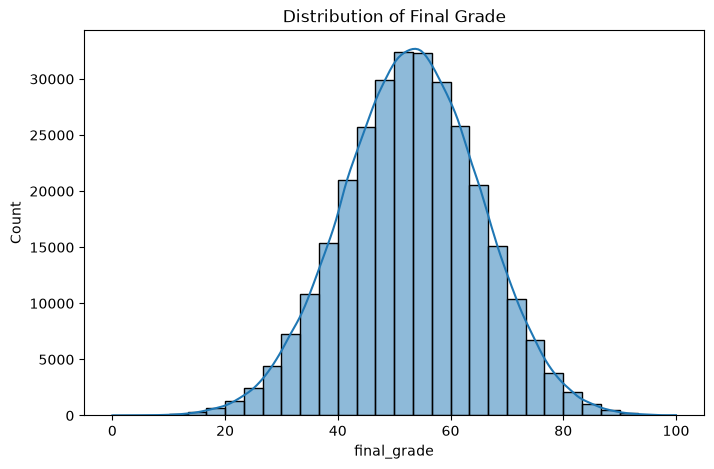

In [23]:
#xploratory Data Analysis (EDA)
#Final GPA Distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df['final_grade'], bins=30, kde=True)
plt.title("Distribution of Final Grade")
plt.show()

In [24]:
print(df.columns.tolist())

['student_id', 'age', 'gender', 'study_hours', 'attendance', 'sleep_hours', 'previous_grade', 'assignments_completed', 'practice_tests_taken', 'group_study_hours', 'notes_quality_score', 'time_management_score', 'motivation_level', 'mental_health_score', 'screen_time', 'social_media_hours', 'family_income', 'parent_education', 'internet_access', 'device_type', 'school_type', 'extracurriculars', 'final_grade', 'grade_category', 'pass_fail']


In [25]:
# Correlation Matrix
corr = df.corr(numeric_only=True)

# Top Correlated Features with Final GPA
correlation = corr["final_grade"].sort_values(ascending=False)

print(correlation)

final_grade              1.000000
pass_fail                0.789673
study_hours              0.430957
previous_grade           0.393373
time_management_score    0.312778
motivation_level         0.306361
assignments_completed    0.282054
practice_tests_taken     0.213146
attendance               0.204748
notes_quality_score      0.201487
mental_health_score      0.159313
sleep_hours              0.122948
group_study_hours        0.075739
student_id               0.001564
school_type              0.000746
parent_education         0.000178
internet_access          0.000042
gender                  -0.000057
extracurriculars        -0.000123
age                     -0.000644
family_income           -0.002263
device_type             -0.002361
social_media_hours      -0.157292
screen_time             -0.157975
grade_category          -0.903759
Name: final_grade, dtype: float64


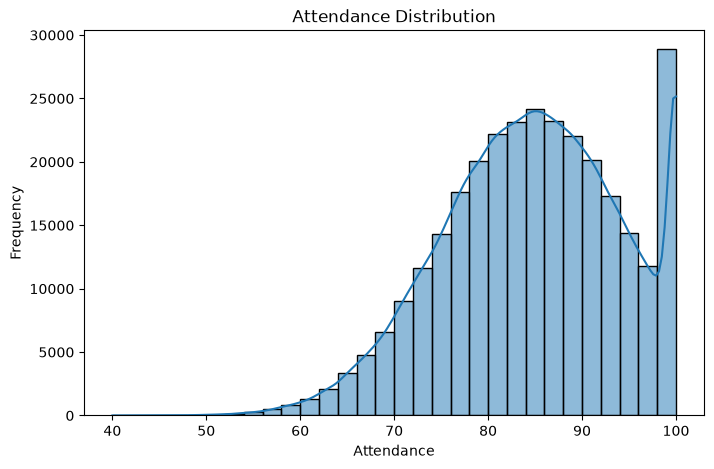

In [26]:
#Attendance Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["attendance"], bins=30, kde=True)

plt.title("Attendance Distribution")
plt.xlabel("Attendance")
plt.ylabel("Frequency")

plt.show()

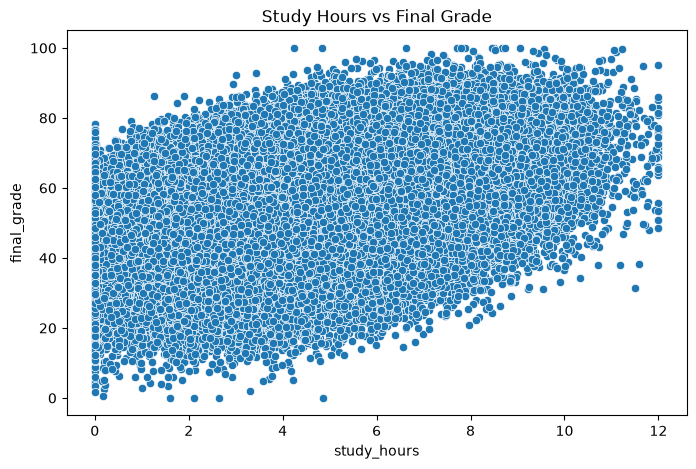

In [27]:
#Study Hours vs Final Grade
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="study_hours",
    y="final_grade",
    data=df
)

plt.title("Study Hours vs Final Grade")

plt.show()

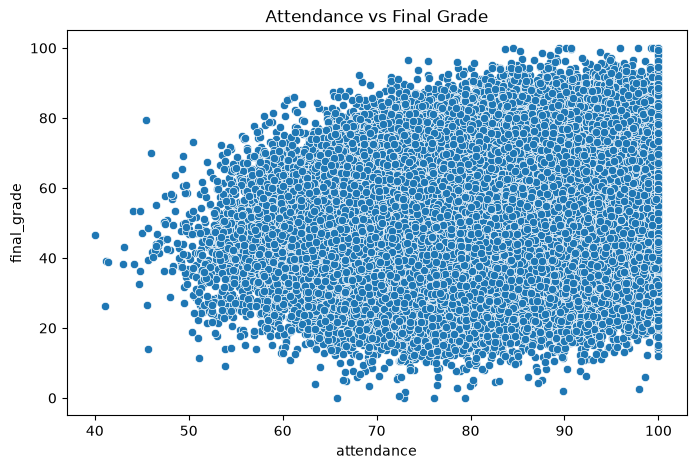

In [28]:
#Attendance vs Final Grade
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="attendance",
    y="final_grade",
    data=df
)

plt.title("Attendance vs Final Grade")

plt.show()

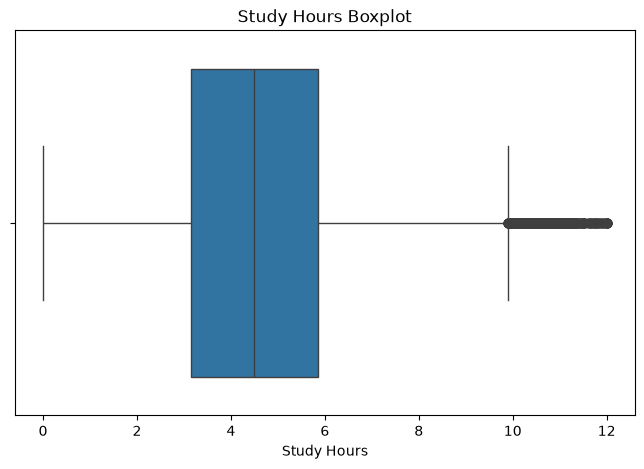

In [29]:
# Box Plot

plt.figure(figsize=(8,5))

sns.boxplot(x=df["study_hours"])

plt.title("Study Hours Boxplot")

plt.xlabel("Study Hours")

plt.show()

In [30]:
#Correlation Matrix
corr = df.corr(numeric_only=True)

corr

,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,...,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,final_grade,grade_category,pass_fail
student_id,1.000000,-0.003339,-3.805878e-03,0.000404,-0.001498,-0.001080,-0.003405,0.003785,0.002660,0.000347,...,-0.001244,-0.002201,0.001450,-0.000014,-0.001497,0.000947,-0.001036,0.001564,-0.000523,0.000276
age,-0.003339,1.000000,4.250573e-03,0.001834,-0.001181,-0.002117,-0.003490,-0.001813,-0.001914,0.000412,...,-0.002011,0.003153,0.000369,-0.000984,0.000105,0.003118,0.002939,-0.000644,0.001242,0.000239
gender,-0.003806,0.004251,1.000000e+00,-0.000817,0.000111,0.001432,-0.000482,0.000944,-0.003797,-0.001447,...,0.001479,-0.002650,-0.001590,0.000112,0.002749,-0.000702,0.002717,-0.000057,0.000111,-0.000869
study_hours,0.000404,0.001834,-8.174826e-04,1.000000,0.000081,0.000072,-0.001439,0.002761,-0.000521,0.000828,...,-0.003675,-0.001620,-0.001977,-0.000089,-0.000303,0.002358,0.000069,0.430957,-0.395589,0.337640
attendance,-0.001498,-0.001181,1.109966e-04,0.000081,1.000000,0.003093,-0.002521,0.002966,-0.001324,0.001038,...,-0.001397,-0.004238,0.001147,0.001316,-0.001246,0.000438,0.002485,0.204748,-0.183178,0.162336
sleep_hours,-0.001080,-0.002117,1.432497e-03,0.000072,0.003093,1.000000,0.002499,0.000481,-0.000246,0.000378,...,-0.000479,0.000274,0.000808,0.003056,-0.002213,-0.000544,-0.000937,0.122948,-0.109818,0.098359
previous_grade,-0.003405,-0.003490,-4.822579e-04,-0.001439,-0.002521,0.002499,1.000000,0.000127,0.001459,0.002410,...,-0.001311,-0.000277,0.003460,0.000916,-0.001985,-0.000800,0.000274,0.393373,-0.353922,0.310598
assignments_completed,0.003785,-0.001813,9.444659e-04,0.002761,0.002966,0.000481,0.000127,1.000000,-0.001008,-0.000972,...,0.001875,0.001120,0.000758,-0.002053,-0.002187,-0.001268,0.003396,0.282054,-0.247803,0.225075
practice_tests_taken,0.002660,-0.001914,-3.797159e-03,-0.000521,-0.001324,-0.000246,0.001459,-0.001008,1.000000,0.001929,...,-0.000767,-0.001869,-0.000952,-0.000583,-0.001267,-0.001918,0.000816,0.213146,-0.194637,0.166548
group_study_hours,0.000347,0.000412,-1.446676e-03,0.000828,0.001038,0.000378,0.002410,-0.000972,0.001929,1.000000,...,0.001649,0.001529,0.002415,-0.000752,0.000880,-0.000802,-0.001653,0.075739,-0.069787,0.060840


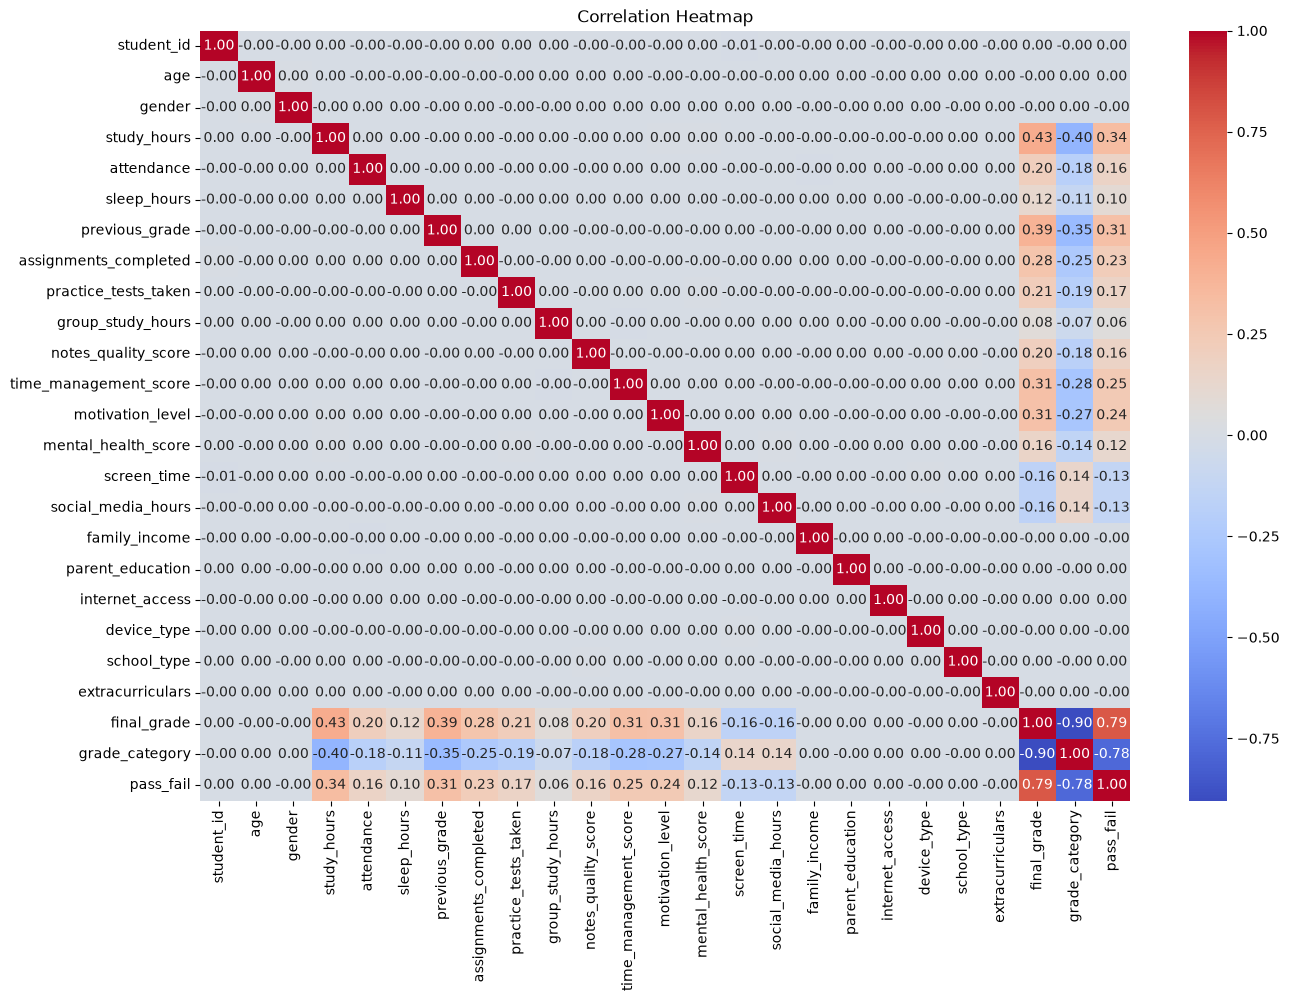

In [31]:
#heatmap
plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [32]:
lr=LinearRegression()

lr.fit(X_train,y_train)

y_pred_lr=lr.predict(X_test)

mae_lr=mean_absolute_error(y_test,y_pred_lr)

rmse_lr=np.sqrt(mean_squared_error(y_test,y_pred_lr))

r2_lr=r2_score(y_test,y_pred_lr)

print("Linear Regression")

print("MAE :",mae_lr)

print("RMSE :",rmse_lr)

print("R2 :",r2_lr)

Linear Regression
MAE : 3.998475609423108
RMSE : 5.008392238330795
R2 : 0.8311130367267804


In [33]:
corr = df.corr(numeric_only=True)["final_grade"].sort_values(ascending=False)
print(corr.head(15))

final_grade              1.000000
pass_fail                0.789673
study_hours              0.430957
previous_grade           0.393373
time_management_score    0.312778
motivation_level         0.306361
assignments_completed    0.282054
practice_tests_taken     0.213146
attendance               0.204748
notes_quality_score      0.201487
mental_health_score      0.159313
sleep_hours              0.122948
group_study_hours        0.075739
student_id               0.001564
school_type              0.000746
Name: final_grade, dtype: float64


In [34]:
#decision tree
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)

dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)

mae_dt = mean_absolute_error(y_test,y_pred_dt)

rmse_dt = np.sqrt(mean_squared_error(y_test,y_pred_dt))

r2_dt = r2_score(y_test,y_pred_dt)

print(r2_dt)

0.5093631918267334


In [35]:
#random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test,y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test,y_pred_rf))

r2_rf = r2_score(y_test,y_pred_rf)

print(r2_rf)

0.7072746805737533


In [39]:
#mpdel comparison
comparison = pd.DataFrame({

"Model":[
"Linear Regression",
"Decision Tree",
"Random Forest"
],

"MAE":[
mae_lr,
mae_dt,
mae_rf
],

"RMSE":[
rmse_lr,
rmse_dt,
rmse_rf
],

"R2 Score":[
r2_lr,
r2_dt,
r2_rf
]

})

comparison.sort_values(
by="R2 Score",
ascending=False,
inplace=True
)

print(comparison)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  3.998476  5.008392  0.831113
2      Random Forest  5.265771  6.593719  0.707275
1      Decision Tree  6.819727  8.536510  0.509363


In [40]:
import os

print(os.getcwd())

c:\Users\ACER\Downloads\IBM-PBEL\UnnatiYadav(Batch 9)--AI-Driven Student Performance Prediction System\notebook
